<a href="https://colab.research.google.com/github/muriloous/ied003/blob/main/atv6/estruturadedados_atv6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Importações

import pandas as pd
import matplotlib.pyplot as plt
import io

In [ ]:
# Criação do arquivo csv

dados_csv = """ano,mes,despesa,valor_despesa
2024,janeiro,alimentação,240.00
2024,janeiro,transporte,130.00
2024,fevereiro,alimentação,250.00
2024,fevereiro,transporte,140.00
2024,março,alimentação,230.00
2024,março,transporte,120.00
2024,abril,alimentação,245.00
2024,abril,transporte,145.00
2024,maio,alimentação,260.00
2024,maio,transporte,150.00
2024,junho,alimentação,225.00
2024,junho,transporte,138.00"""

with open('despesas.csv', 'w') as f:
    f.write(dados_csv)

### Leitura do arquivo CSV e Exploração Inicial

In [ ]:
# Leitura do arquivo despesas.csv para um DataFrame
df = pd.read_csv('despesas.csv')

# Exiba as 5 primeiras linhas do DataFrame
print("\n5 primeiras linhas do df:")
print(df.head())


5 primeiras linhas do df:
    ano        mes      despesa  valor_despesa
0  2024    janeiro  alimentação          240.0
1  2024    janeiro   transporte          130.0
2  2024  fevereiro  alimentação          250.0
3  2024  fevereiro   transporte          140.0
4  2024      março  alimentação          230.0

Informações sobre os tipos de dados do df:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ano            12 non-null     int64  
 1   mes            12 non-null     object 
 2   despesa        12 non-null     object 
 3   valor_despesa  12 non-null     float64
dtypes: float64(1), int64(1), object(2)
memory usage: 516.0+ bytes


In [ ]:
# Mostre informações sobre tipos
print("\nInformações sobre os tipos de dados do df:")
df.info()

Coluna 'mês' após conversão:
0      janeiro
1      janeiro
2    fevereiro
3    fevereiro
4        março
Name: mes, dtype: category
Categories (6, object): ['janeiro' < 'fevereiro' < 'março' < 'abril' < 'maio' < 'junho']


In [ ]:
# Converta a coluna mes para o tipo categórico e defina a ordem correta dos meses de janeiro a junho.
meses_ordem = ['janeiro', 'fevereiro', 'março', 'abril', 'maio', 'junho']
df['mes'] = pd.Categorical(df['mes'], categories=meses_ordem, ordered=True)

print("Coluna 'mês' após conversão:")
print(df.head()['mes'])

Coluna 'mês' após conversão:
0      janeiro
1      janeiro
2    fevereiro
3    fevereiro
4        março
Name: mes, dtype: category
Categories (6, object): ['janeiro' < 'fevereiro' < 'março' < 'abril' < 'maio' < 'junho']


In [ ]:
# Calcule o total de despesas por mês (agrupando por mes e somando valor_despesa).
total_despesa_por_mes = df.groupby('mes')['valor_despesa'].sum()
print("\nTotal de despesas por mês:")
print(total_despesa_por_mes)


Total de despesas por mês:
mes
janeiro      370.0
fevereiro    390.0
março        350.0
abril        390.0
maio         410.0
junho        363.0
Name: valor_despesa, dtype: float64
{'janeiro': np.float64(370.0), 'fevereiro': np.float64(390.0), 'março': np.float64(350.0), 'abril': np.float64(390.0), 'maio': np.float64(410.0), 'junho': np.float64(363.0)}


/tmp/ipykernel_43886/3402562719.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  total_despesa_por_mes = df.groupby('mes')['valor_despesa'].sum()


In [ ]:
# Calcule o total de despesas por tipo de despesa (agrupando por despesa e somando valor_despesa).
total_despesa_por_tipo = df.groupby('despesa')['valor_despesa'].sum()
print("\nTotal de despesas por tipo de despesa:")
print(total_despesa_por_tipo)


Total de despesas por tipo de despesa:
despesa
alimentação    1450.0
transporte      823.0
Name: valor_despesa, dtype: float64


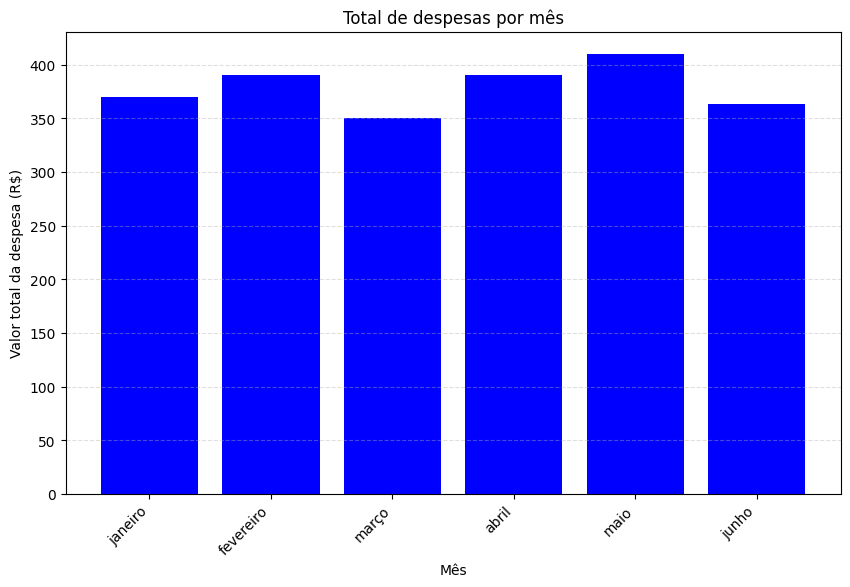

In [ ]:
# Gere um gráfico de barras com Matplotlib mostrando o total de despesas por mês, incluindo título, rótulos nos eixos, e rótulos de mês legíveis.
plt.figure(figsize=(10, 6))
plt.bar(total_despesa_por_mes.index, total_despesa_por_mes.values, color='blue')
plt.xlabel('Mês')
plt.ylabel('Valor total da despesa (R$)')
plt.title('Total de despesas por mês')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.show()

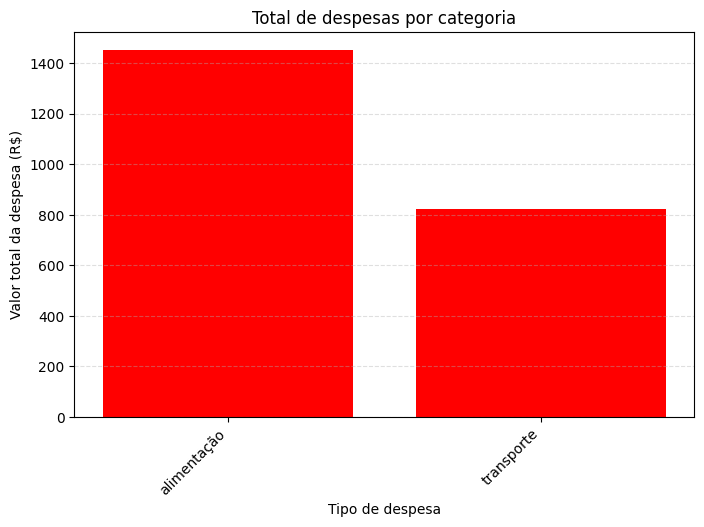

In [ ]:
# Gere um gráfico de barras com o total de despesas por categoria (despesa).
plt.figure(figsize=(8, 5))
plt.bar(total_despesa_por_tipo.index, total_despesa_por_tipo.values, color='red')
plt.xlabel('Tipo de despesa')
plt.ylabel('Valor total da despesa (R$)')
plt.title('Total de despesas por categoria')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.show()

In [ ]:
# Escreva um relatório dinâmico (use uma f-string com funções de análise nas variáveis total_despesa_por_mes e total_despesa_por_tipo), indicando: em que meses os gastos são maiores, quais categorias consomem mais recursos, e qualquer padrão identificado, baseando-se nos gráficos gerados. Não use textos com todas as iniciais maiúsculas (estilo "title"), capitalize apenas onde necessário. Não use markdown ou negrito, apenas texto simples. Imprima na tela e também exporte para um txt.

mes_maior_gasto = total_despesa_por_mes.idxmax()
valor_maior_gasto = total_despesa_por_mes.max()

categoria_maior_gasto = total_despesa_por_tipo.idxmax()
valor_categoria_maior_gasto = total_despesa_por_tipo.max()

media_despesa_por_categoria = dict(df.groupby(['despesa'])['valor_despesa'].mean())
dp_despesa_por_categoria = dict(df.groupby(['despesa'])['valor_despesa'].std())

media_despesa_por_mes = dict(df.groupby(['mes'], observed=False)['valor_despesa'].mean())
dp_despesa_por_mes = dict(df.groupby(['mes'], observed=False)['valor_despesa'].std())

# Formatar o relatório dinâmico
relatorio = f"""
Relatório de análise de despesas:

Observando os dados e gráficos, os meses com maiores gastos foram {mes_maior_gasto} com um total de R$ {valor_maior_gasto:.2f}.

A categoria que mais consome recursos é {categoria_maior_gasto} com um total de R$ {valor_categoria_maior_gasto:.2f}.

A média por categoria é: \n{'\n'.join([f'{k.capitalize()}: R${round(v, 2)} (Desvio padrão: R${round(dp_despesa_por_categoria[k], 2)})' for k, v in media_despesa_por_categoria.items()])}

A média por mês é: \n{'\n'.join([f'{k.capitalize()}: R${round(v, 2)} (Desvio padrão: R${round(dp_despesa_por_mes[k], 2)})' for k, v in media_despesa_por_mes.items()])}
"""

# Imprimir o relatório na tela
print(relatorio)

# Exportar o relatório para um arquivo txt
with open('relatorio_despesas.txt', 'w', encoding='utf-8') as f:
    f.write(relatorio)


Relatório de análise de despesas:

Observando os dados e gráficos, os meses com maiores gastos foram maio com um total de R$ 410.00.

A categoria que mais consome recursos é alimentação com um total de R$ 1450.00.

A média por categoria é: 
Alimentação: R$241.67 (Desvio padrão: R$12.91)
Transporte: R$137.17 (Desvio padrão: R$10.78)

A média por mês é: 
Janeiro: R$185.0 (Desvio padrão: R$77.78)
Fevereiro: R$195.0 (Desvio padrão: R$77.78)
Março: R$175.0 (Desvio padrão: R$77.78)
Abril: R$195.0 (Desvio padrão: R$70.71)
Maio: R$205.0 (Desvio padrão: R$77.78)
Junho: R$181.5 (Desvio padrão: R$61.52)

